# K-Means Economic Regime Identification

K-Means clustering of economic states across 9 nations (G7 + Australia, South Korea) from 2001–2018. The goal is to discover **latent macroeconomic regimes** — recurring patterns in macro conditions — while recognizing that upstream feature selection was recession-target-informed.

K-Means itself is fit without labels on country-month observations using multi-domain indicators. The discovered regimes are then characterized post-hoc by examining cluster centers, temporal patterns, and geographic distributions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score,
    davies_bouldin_score, adjusted_rand_score
)
import warnings
warnings.filterwarnings('ignore')

from model_utils import (
    load_clustering_data, print_cluster_summary, plot_silhouette_analysis,
    plot_center_heatmaps, plot_feature_boxplots,
    plot_regime_composition_over_time, plot_country_regime_analysis,
    plot_pca_analysis, plot_tsne, plot_recession_overlay, plot_stability_ari,
)

df_cluster, CLUSTER_FEATURES, X_scaled, scaler = load_clustering_data(
    '../data/milestone_ii_preprocessed_complete.pkl',
    '../data/selected_features_complete.pkl',
)

Dataset shape: (1854, 239)
Date range: 2001-11 to 2018-12
Countries (9): ['Australia', 'Canada', 'France', 'Germany', 'Italy', 'Japan', 'South Korea', 'UK', 'USA']

Clustering features (20):
   1. copper_lag_3mo
   2. comp_consumer_conf
   3. copper_lag_6mo
   4. cli
   5. copper
   6. real_rate_10yr
   7. vix_rolling_mean_12mo_lag_12mo
   8. real_gdp_log_6mo
   9. national_share_price_rolling_std_12mo
  10. yield_curve
  11. sahm_value_lag_12mo
  12. real_rate_10yr_lag_3mo
  13. epu_rolling_mean_12mo_lag_12mo
  14. vix_log_3mo
  15. gps_log_1mo
  16. gdp_qoq_growth_lag_12mo
  17. national_share_price_log_6mo
  18. cpi
  19. unemployment_rate_diff_6mo
  20. unemployment_rate_diff_1mo

Feature matrix: 1854 observations × 20 features
NaN rows dropped: 0


## Feature Selection for Clustering

Features are loaded from the feature selection pipeline (`selected_features_complete.pkl`), which identified 20 features through a three-stage process (correlation removal, permutation importance, LASSO L1). Because that upstream selection used recession-target information, this notebook should be interpreted as **target-informed unsupervised clustering** rather than fully target-agnostic discovery.

Country dummy variables are excluded so clustering emphasizes shared macroeconomic states rather than explicit geographic identity.

## Determining Optimal Number of Clusters

Four internal validation metrics guide the choice of *k*:
- **Elbow method (inertia)**: Look for a bend where adding clusters yields diminishing returns in within-cluster sum of squares
- **Silhouette score**: How similar points are to their own cluster vs. neighboring clusters (higher = better, range \[-1, 1\])
- **Calinski-Harabasz index**: Ratio of between-cluster to within-cluster dispersion (higher = better)
- **Davies-Bouldin index**: Average similarity between each cluster and its most similar neighbor (lower = better)

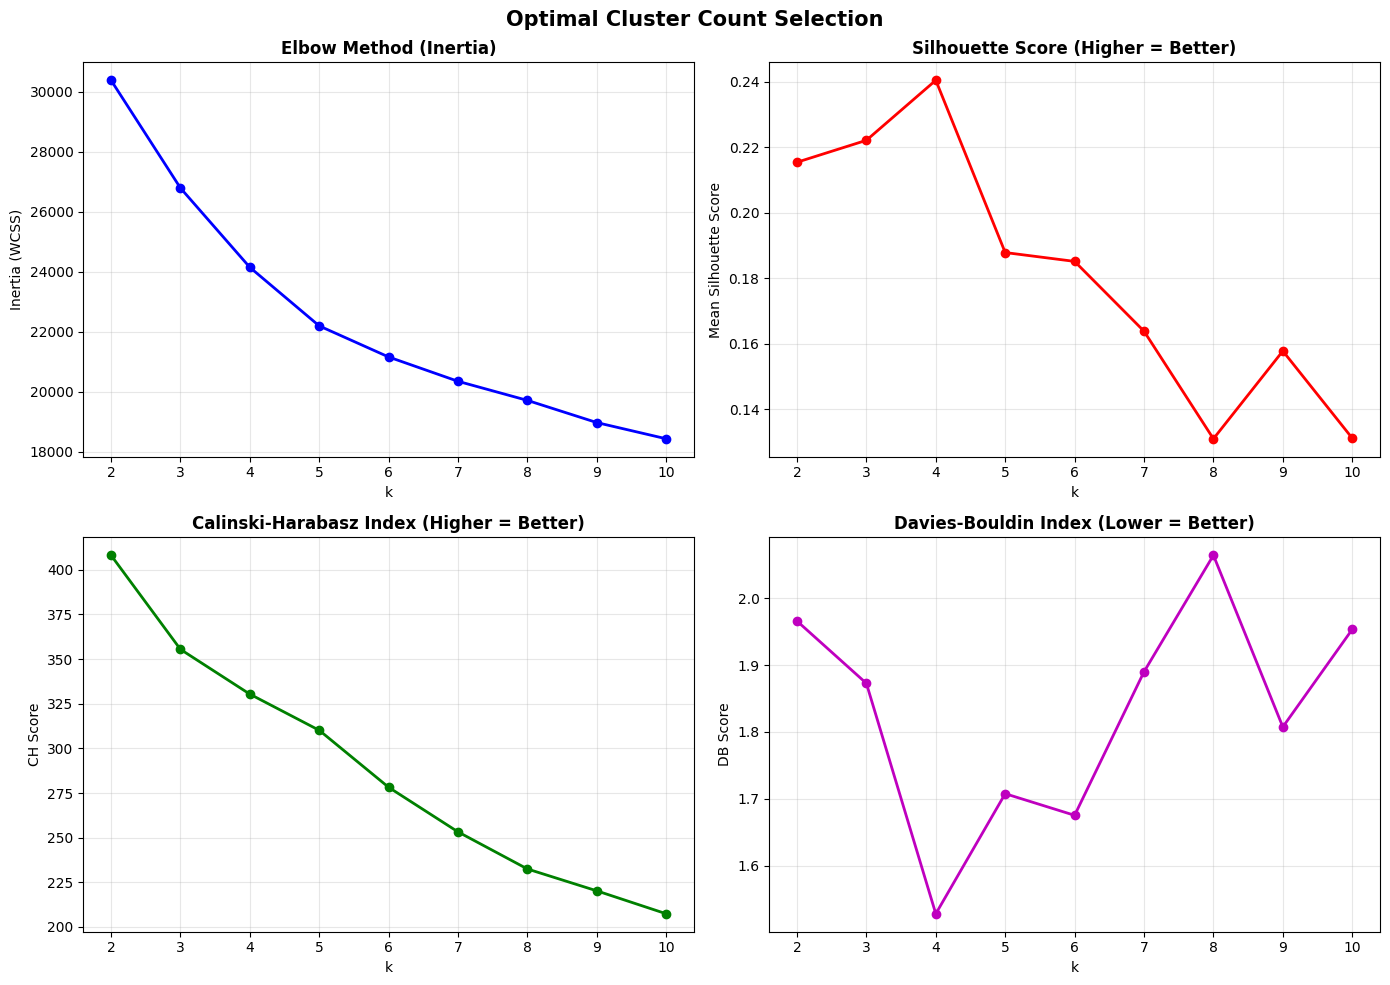

       Inertia  Silhouette  Calinski-Harabasz  Davies-Bouldin
k                                                            
2   30384.0315      0.2154           408.1398          1.9660
3   26790.6821      0.2221           355.4506          1.8727
4   24144.7998      0.2404           330.3696          1.5278
5   22191.8455      0.1878           310.1161          1.7076
6   21156.0232      0.1851           278.1951          1.6752
7   20344.7363      0.1639           253.2189          1.8900
8   19708.1206      0.1310           232.4531          2.0645
9   18968.3992      0.1578           220.2077          1.8075
10  18428.2056      0.1312           207.3748          1.9535

Best k by silhouette score: 4


In [2]:
K_RANGE = range(2, 11)
inertias, sil_scores, ch_scores, db_scores = [], [], [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(K_RANGE, inertias, 'bo-', linewidth=2)
axes[0, 0].set_title('Elbow Method (Inertia)', fontweight='bold')
axes[0, 0].set_xlabel('k')
axes[0, 0].set_ylabel('Inertia (WCSS)')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(K_RANGE, sil_scores, 'ro-', linewidth=2)
axes[0, 1].set_title('Silhouette Score (Higher = Better)', fontweight='bold')
axes[0, 1].set_xlabel('k')
axes[0, 1].set_ylabel('Mean Silhouette Score')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(K_RANGE, ch_scores, 'go-', linewidth=2)
axes[1, 0].set_title('Calinski-Harabasz Index (Higher = Better)', fontweight='bold')
axes[1, 0].set_xlabel('k')
axes[1, 0].set_ylabel('CH Score')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(K_RANGE, db_scores, 'mo-', linewidth=2)
axes[1, 1].set_title('Davies-Bouldin Index (Lower = Better)', fontweight='bold')
axes[1, 1].set_xlabel('k')
axes[1, 1].set_ylabel('DB Score')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Optimal Cluster Count Selection', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary table
results_df = pd.DataFrame({
    'k': list(K_RANGE),
    'Inertia': inertias,
    'Silhouette': sil_scores,
    'Calinski-Harabasz': ch_scores,
    'Davies-Bouldin': db_scores,
}).set_index('k')
print(results_df.round(4))

best_k_sil = list(K_RANGE)[np.argmax(sil_scores)]
print(f"\nBest k by silhouette score: {best_k_sil}")

### Interpretation

Three of four metrics support **k = 4** as the most useful operating point:

- **Inertia** shows a gradual decline with a moderate elbow around k = 4–5, where adding more clusters yields diminishing reductions in within-cluster variance.
- **Silhouette score** peaks at k = 4 (0.240), indicating observations are best-matched to their assigned clusters at this granularity.
- **Davies-Bouldin index** reaches its minimum at k = 4 (1.528), meaning clusters are maximally separated relative to their internal spread.
- **Calinski-Harabasz** is highest at k = 2 and then decreases; this reflects a preference for fewer, broader partitions, while silhouette/DB favor the richer k = 4 structure.

A silhouette score of 0.24 is moderate, typical for macroeconomic data where regimes blend rather than forming perfectly discrete groups. We therefore select k = 4 as a trade-off between internal separation and interpretive granularity.

## K-Means Clustering (k = 4)

With the optimal cluster count determined, we fit the final K-Means model with k = 4 and 20 random initializations (`n_init=20`) to reduce sensitivity to starting conditions. Each of the 1,854 observations (a country-month pair) is assigned to one of four discovered economic regimes.

In [3]:
OPTIMAL_K = best_k_sil
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=20)
df_cluster['regime'] = kmeans.fit_predict(X_scaled)

print_cluster_summary(X_scaled, df_cluster['regime'].values, OPTIMAL_K,
                      'K-Means', inertia=kmeans.inertia_)

K-Means fitted with 4 clusters/states

Internal Validation Metrics:
  Silhouette Score:      0.2403
  Calinski-Harabasz:     330.3710
  Davies-Bouldin:        1.5278
  Inertia:               24144.76

Cluster Sizes:
  Regime 0:   112 observations (6.0%)
  Regime 1:   491 observations (26.5%)
  Regime 2:   175 observations (9.4%)
  Regime 3:  1076 observations (58.0%)


### Interpretation

The model assigns 1,854 country-month observations into four regimes of markedly different sizes:

| Regime | Size | Share | Initial Interpretation |
|--------|------|-------|----------------------|
| Regime 3 | 1,076 | 58.0% | Dominant regime — likely represents "normal" economic conditions |
| Regime 1 | 491 | 26.5% | Second-largest — a distinct but common alternative state |
| Regime 2 | 175 | 9.4% | Uncommon regime — possibly transitional or recovery periods |
| Regime 0 | 112 | 6.0% | Rarest regime — likely captures extreme or crisis conditions |

The uneven distribution is expected: economies spend most of their time in stable states and only briefly occupy extreme regimes. The silhouette score of 0.240 confirms moderate but meaningful cluster separation in this high-dimensional economic feature space.

## Silhouette Analysis

The silhouette plot shows how well each observation fits its assigned cluster. Values near +1 indicate strong cluster membership, values near 0 indicate boundary points, and negative values suggest potential misassignment.

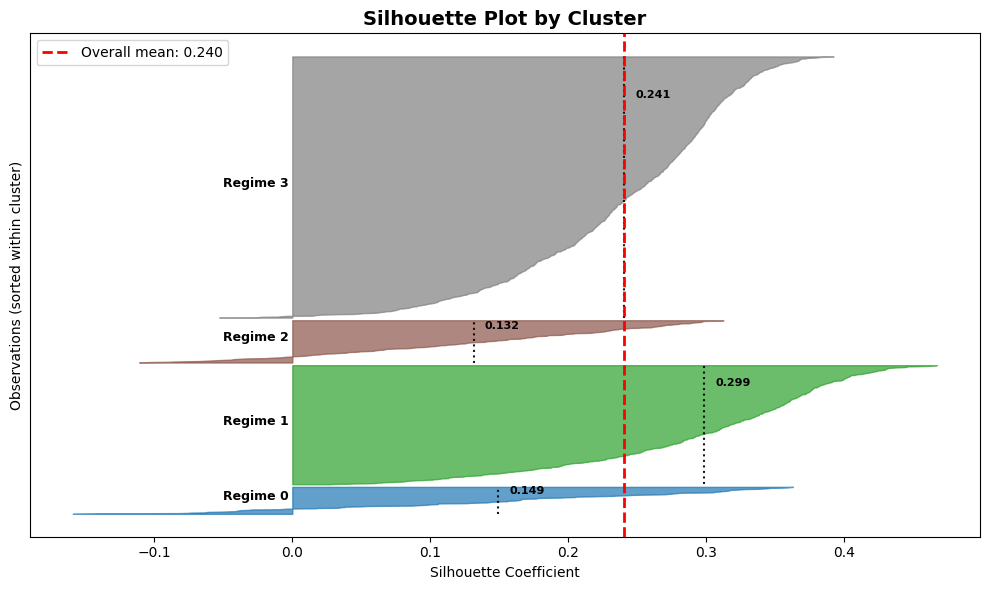

Per-Cluster Silhouette Statistics:
  Regime 0: mean=0.149, min=-0.159, max=0.363, % negative=19.6%
  Regime 1: mean=0.299, min=0.027, max=0.467, % negative=0.0%
  Regime 2: mean=0.132, min=-0.111, max=0.313, % negative=14.3%
  Regime 3: mean=0.241, min=-0.053, max=0.393, % negative=0.7%


In [4]:
plot_silhouette_analysis(X_scaled, df_cluster['regime'].values, OPTIMAL_K)

### Interpretation

The silhouette plot reveals important differences in cluster cohesion:

- **Regime 1** is the most coherent cluster (mean silhouette = 0.299, 0% negative), meaning every observation assigned to Regime 1 is closer to its own centroid than to any other.
- **Regime 3** is also well-defined (mean = 0.241, only 0.7% negative), consistent with its role as the dominant "normal" state.
- **Regime 0** (mean = 0.149, 19.6% negative) and **Regime 2** (mean = 0.132, 14.3% negative) show weaker cohesion with some misassigned boundary points. These smaller, more extreme regimes share features with neighboring clusters, which is expected for transitional economic states.

The red dashed line shows the overall mean silhouette of 0.240. Regimes 1 and 3 exceed this threshold, while Regimes 0 and 2 fall below it — suggesting the extreme regimes are harder to crisply separate from the broader economic landscape.

## Cluster Profiling (Regime Characterization)

Examining cluster centers reveals what economic conditions define each regime. The first heatmap shows centers in original units for direct interpretation; the second shows standardized values highlighting each regime's deviation from the dataset mean.

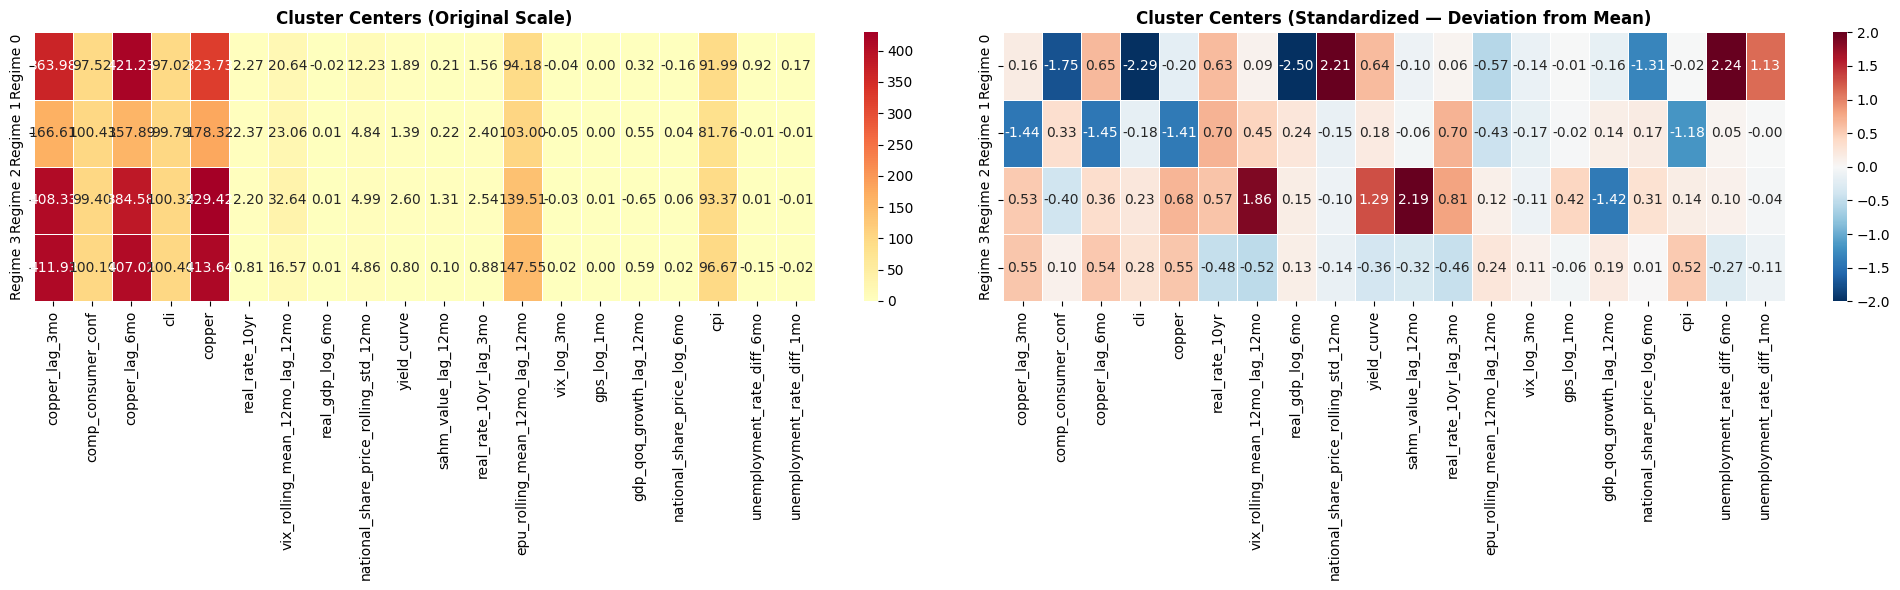

Regime Profiles (Original Scale):
                                         Regime 0    Regime 1    Regime 2    Regime 3
copper_lag_3mo                         363.976786  166.608758  408.334286  411.931877
comp_consumer_conf                      97.523896  100.427734   99.403998  100.098014
copper_lag_6mo                         421.234821  157.885540  384.583429  407.024349
cli                                     97.020371   99.793090  100.324612  100.396353
copper                                 323.733929  178.319756  429.420571  413.640613
real_rate_10yr                           2.268214    2.369769    2.198265    0.807382
vix_rolling_mean_12mo_lag_12mo          20.640789   23.064800   32.635681   16.572278
real_gdp_log_6mo                        -0.023303    0.011790    0.010635    0.010362
national_share_price_rolling_std_12mo   12.234374    4.837759    4.990121    4.855888
yield_curve                              1.890414    1.394500    2.601094    0.800522
sahm_value_lag_12mo 

In [5]:
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
plot_center_heatmaps(centers_original, kmeans.cluster_centers_, CLUSTER_FEATURES, OPTIMAL_K)

### Regime Characterization

Examining the cluster centers reveals four distinct economic states:

**Regime 0 — Acute Crisis** (6.0% of observations)
- Sharply negative GDP growth (`real_gdp_log_6mo = −0.023`)
- Surging unemployment (`unemployment_rate_diff_6mo = +0.92`, the highest across regimes)
- Extreme stock market volatility (`national_share_price_rolling_std_12mo = 12.2`, ~2.5× other regimes)
- Declining equity prices (`national_share_price_log_6mo = −0.16`)
- Below-trend composite leading indicator (`cli = 97.0`)
- Falling copper prices relative to recent lags, signaling abrupt demand contraction

**Regime 1 — Low-Commodity / Early-Cycle** (26.5%)
- Very low copper prices (178 vs. 400+ in other regimes) and low CPI (81.8), reflecting the early 2000s low-commodity-price environment
- Moderate real rates (~2.4%) and stable labor markets
- VIX memory elevated but not extreme (`vix_rolling_mean_12mo_lag_12mo = 23.1`)
- Positive GDP growth and near-trend CLI

**Regime 2 — Post-Crisis Recovery** (9.4%)
- Very high lagged VIX (`vix_rolling_mean_12mo_lag_12mo = 32.6`) and SAHM indicator (`sahm_value_lag_12mo = 1.31`) — the "memory" of a recent recession
- Negative lagged GDP growth (`gdp_qoq_growth_lag_12mo = −0.65`) confirming recent contraction
- Steep yield curve (2.60) — typical of central bank easing after a downturn
- High economic policy uncertainty (`epu_rolling_mean_12mo_lag_12mo = 139.5`)
- Current indicators improving (positive CLI, moderate copper)

**Regime 3 — Broad Low-Volatility / Low-Rate State** (58.0%)
- Low volatility (`VIX lag = 16.6`), low SAHM (0.10), and improving labor market (`unemployment_rate_diff = −0.15`)
- Low real interest rates (0.81%), consistent with the post-2010 low-rate environment
- High copper and CPI (96.7), reflecting stronger demand conditions than Regime 1
- Flat yield curve (0.80), consistent with mature-cycle behavior in parts of the sample
- Interpreted as a broad macro state rather than a pure expansion-only regime

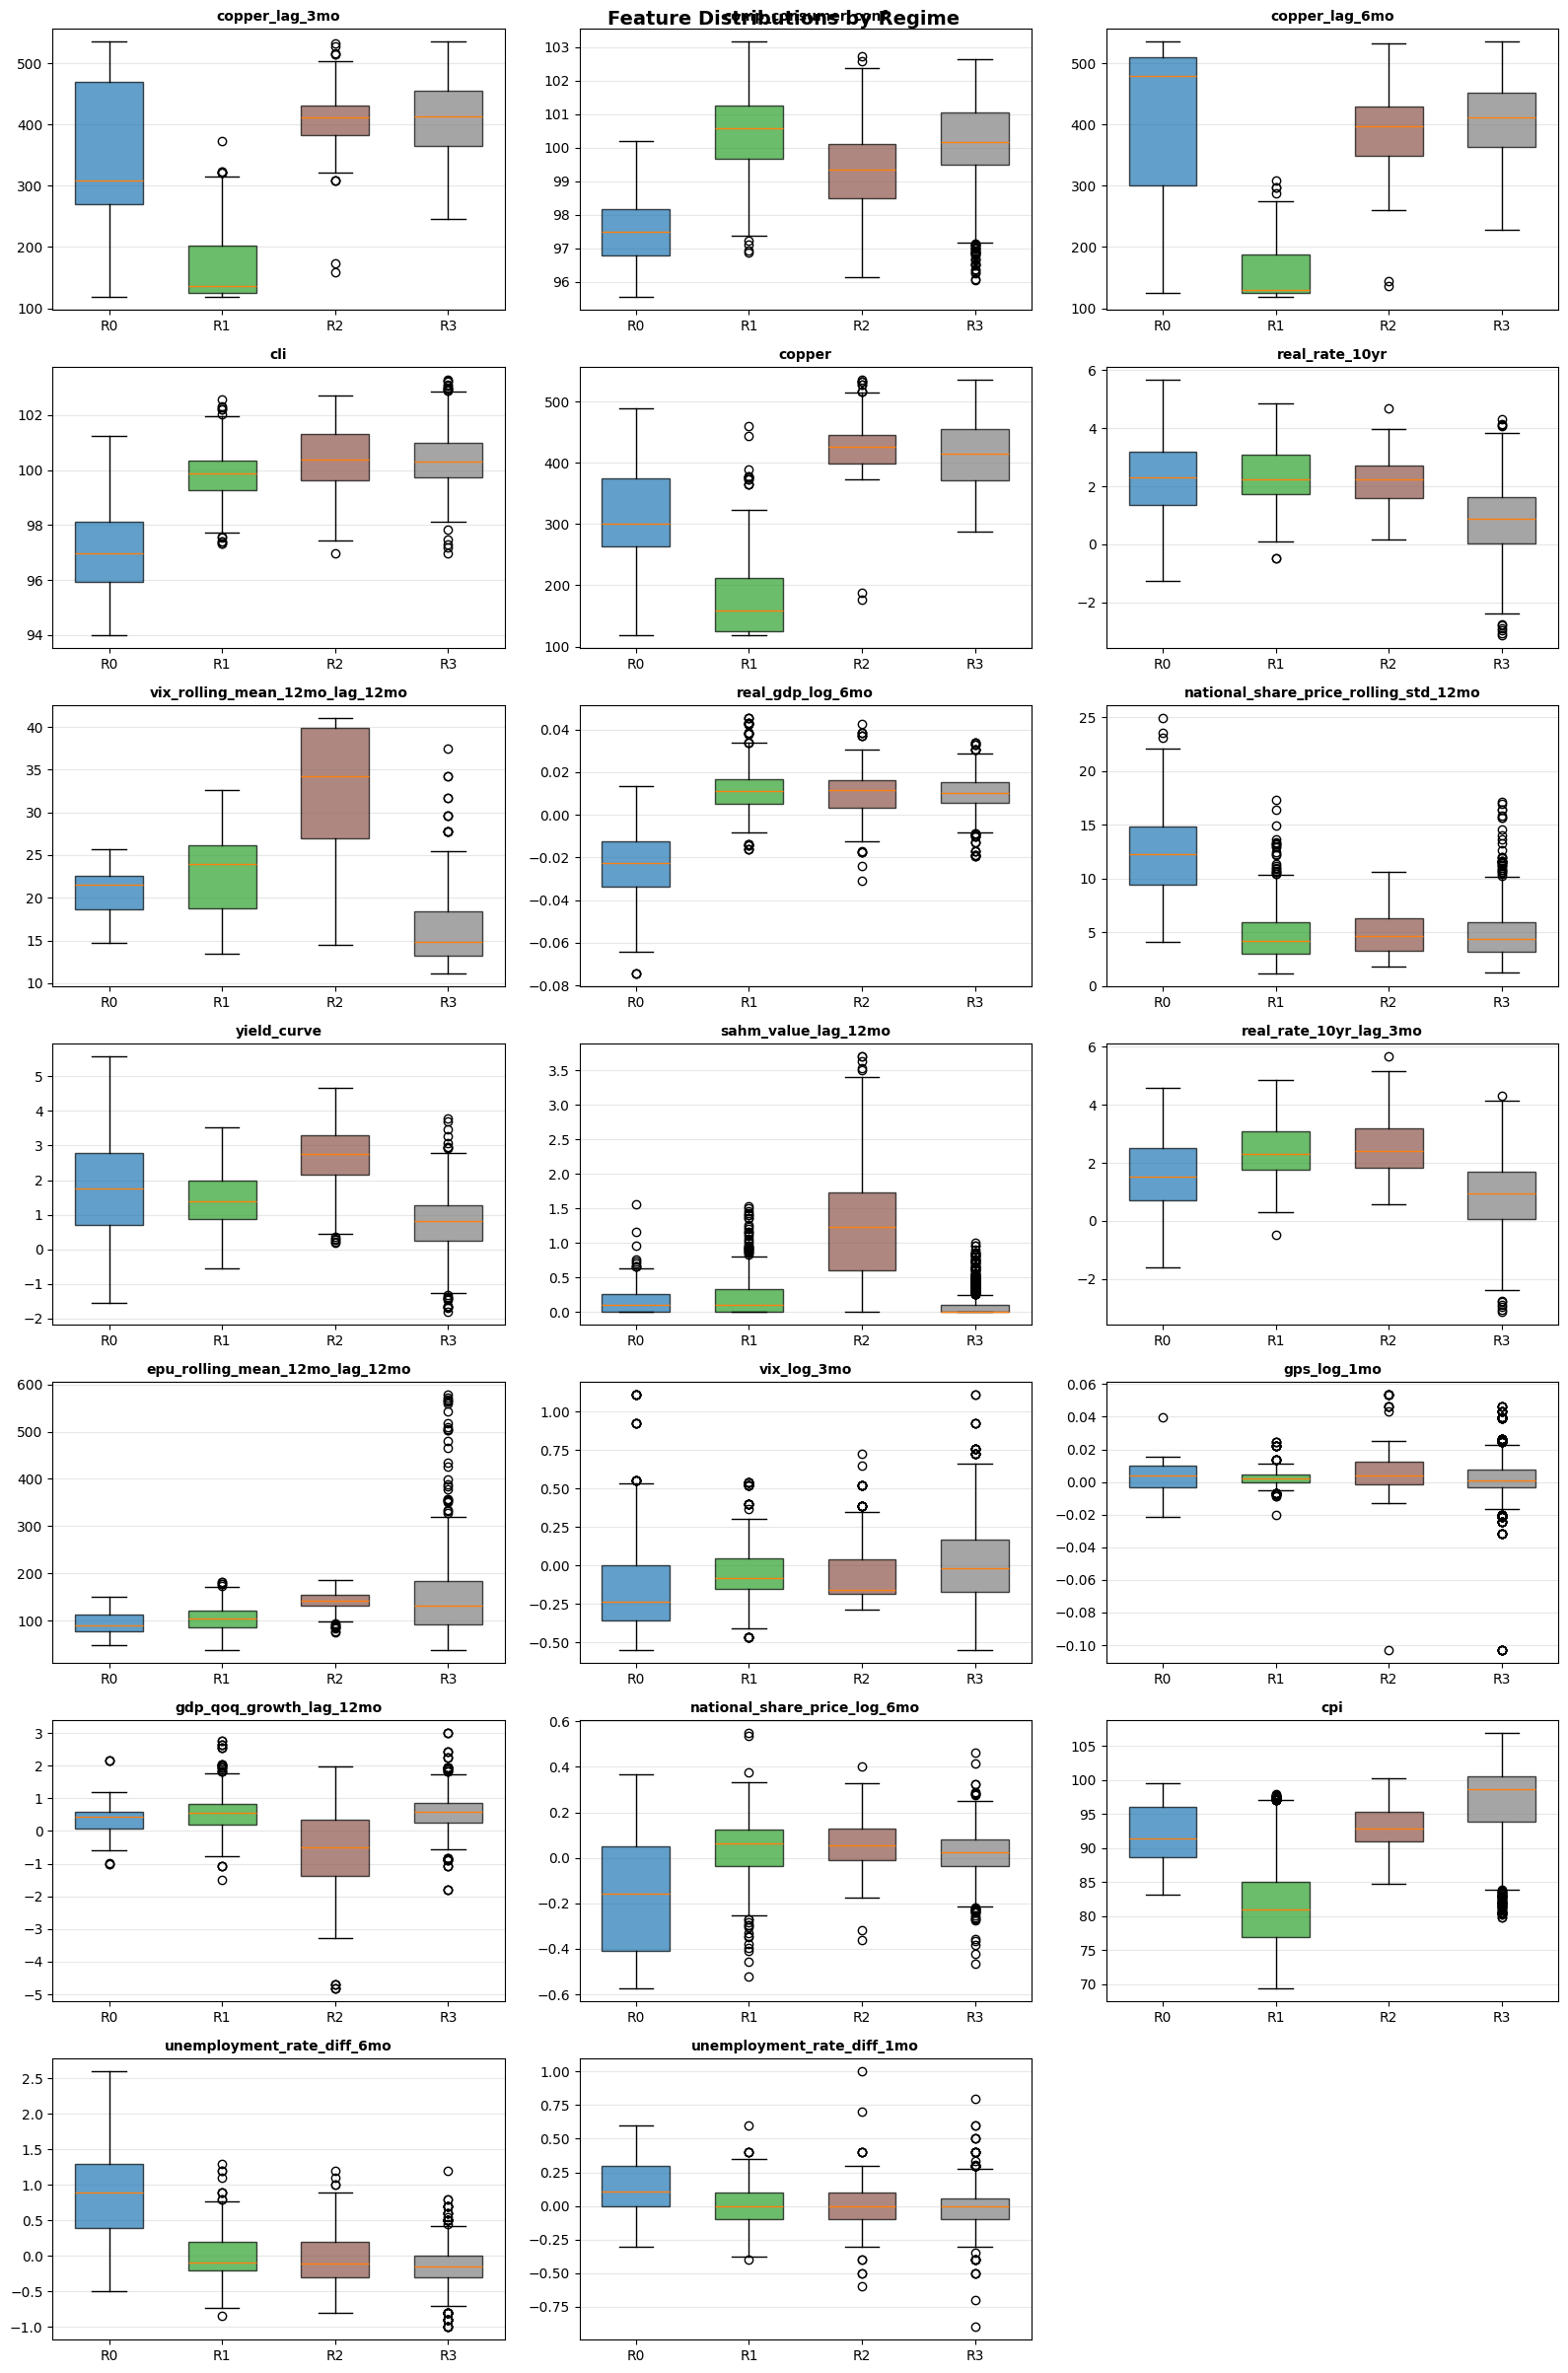

In [6]:
plot_feature_boxplots(df_cluster, CLUSTER_FEATURES, OPTIMAL_K)

### Interpretation

The box plots confirm the heatmap characterization and reveal the within-cluster spread:

- **Copper prices** cleanly separate Regime 1 (low, tight distribution ~100–250) from the other regimes (~300–550), confirming its role as a period-specific commodity regime.
- **Stock market volatility** (`national_share_price_rolling_std_12mo`) has a dramatically wider distribution in Regime 0, with a median 2–3× higher than other regimes.
- **Unemployment acceleration** (`unemployment_rate_diff_6mo`) shows Regime 0 with a distribution shifted far above zero, while Regime 3 is centered below zero (improving labor markets).
- **Yield curve** shows notable differences: Regimes 0 and 2 have steep curves (1.9 and 2.6), while Regime 3 is flat (~0.8), consistent with different monetary policy environments.
- **VIX and SAHM lagged indicators** show the widest separation for Regime 2, confirming its "post-crisis memory" characterization.

Some features show substantial overlap between regimes (e.g., `cpi`, `gps_log_1mo`), indicating that no single indicator defines a regime — it is the combination of features that distinguishes economic states.

## Temporal Analysis

How do regimes evolve over time? The stacked area chart shows what fraction of the 9 countries occupy each regime at every date. The heatmap shows regime assignments per country, revealing synchronized vs. idiosyncratic regime transitions.

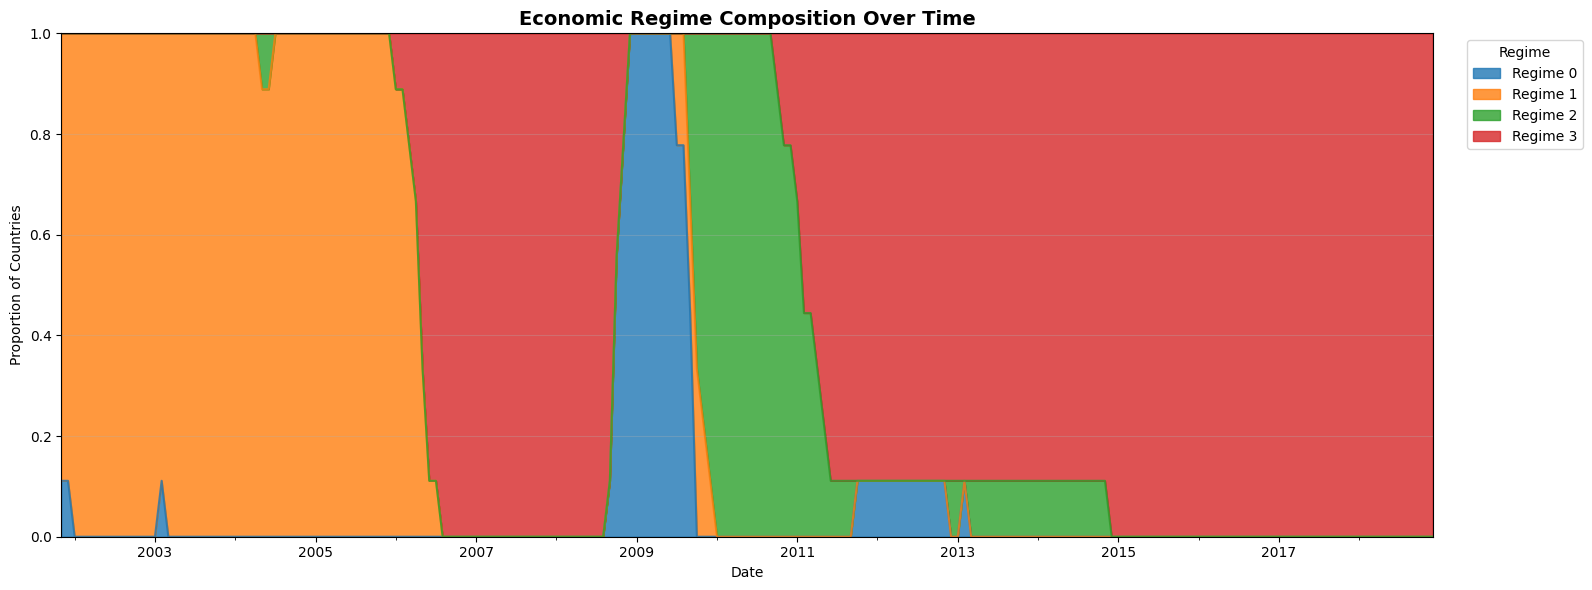

In [7]:
plot_regime_composition_over_time(df_cluster, OPTIMAL_K)

### Interpretation

The stacked area chart reveals clear temporal structure in regime assignments:

- **Regime 1** dominates the early period (2002–2005), consistent with its characterization as a low-commodity-price era. It virtually disappears after 2006 as copper and commodity prices rose.
- **Regime 0** appears in sharp, concentrated bursts — most prominently during the 2008–2009 Global Financial Crisis, when it captures a large share of countries simultaneously. This synchronized appearance confirms it as a global crisis regime.
- **Regime 2** emerges immediately after Regime 0 recedes (2009–2011), consistent with the post-crisis recovery interpretation. It also appears briefly around 2012–2013 during the European debt crisis aftermath.
- **Regime 3** steadily grows to dominate the 2013–2018 period, reflecting the prolonged post-crisis expansion with low rates and low volatility.

The transitions between regimes are not instantaneous — there are periods where multiple regimes coexist across countries, reflecting the asynchronous nature of global economic cycles.

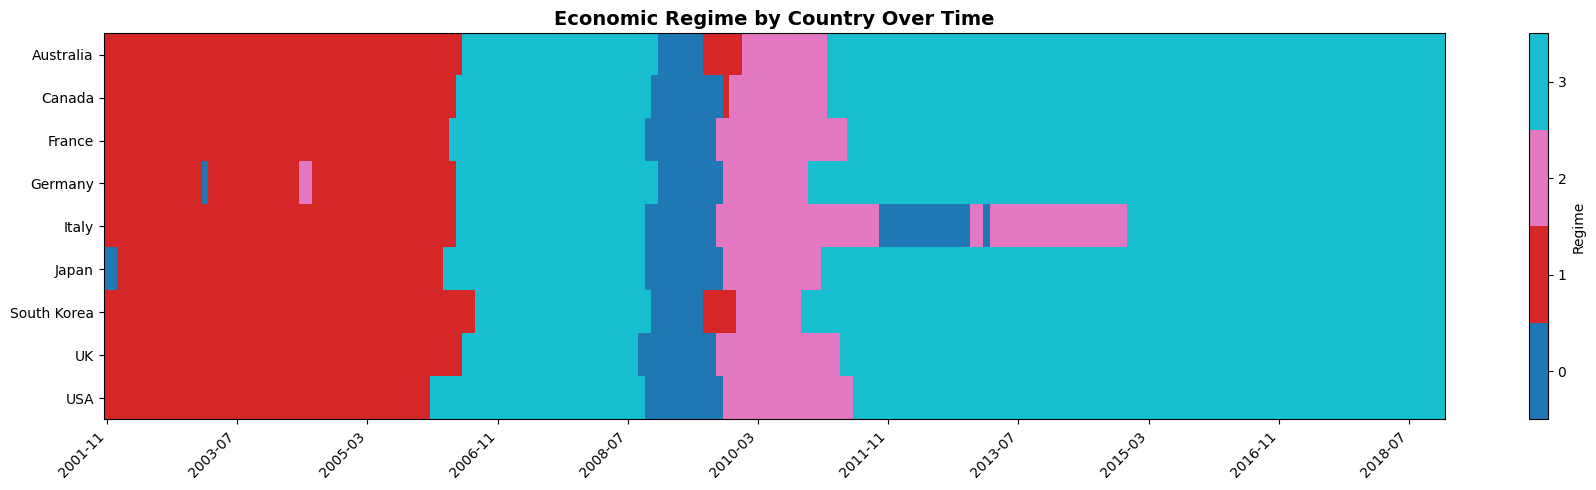

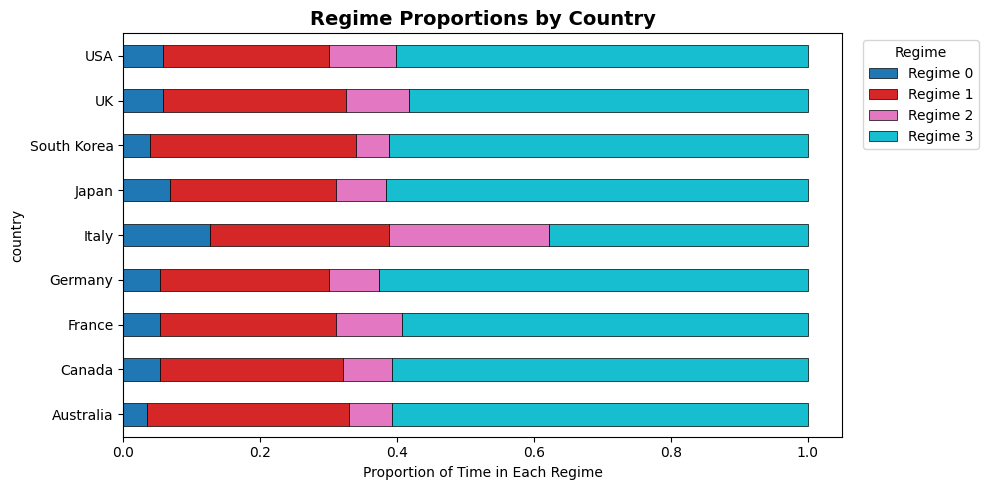

In [8]:
plot_country_regime_analysis(df_cluster, OPTIMAL_K)

### Interpretation

The country-regime heatmap and proportion chart reveal both synchronization and divergence:

**Synchronized transitions**: All nine countries shift into crisis-related regimes around 2008–2009, confirming the global nature of the financial crisis. The transition back to Regime 3 (expansion) is more gradual and staggered.

**Country-specific patterns**:
- **Japan** and **Italy** spend more time in non-expansion regimes, reflecting their structural economic challenges (Japan's deflationary environment, Italy's slow recovery from the European debt crisis).
- **Australia** transitions to Regime 3 earlier than most countries, consistent with its avoidance of a technical recession during the GFC due to commodity exports to China.
- **USA** and **UK** show relatively clean transitions through the regime sequence: expansion → crisis → recovery → expansion.

The horizontal bar chart quantifies these differences: countries with more balanced regime distributions experienced more economic turbulence over the sample period, while those dominated by Regime 3 enjoyed more stable conditions.

## PCA & t-SNE Visualization

Two complementary projections of the 20-dimensional feature space to 2D:
- **PCA** (linear): Preserves global variance structure. The loadings plot shows which original features drive each principal component.
- **t-SNE** (non-linear): Preserves local neighborhood structure, revealing cluster shapes and separations that linear projections may miss.

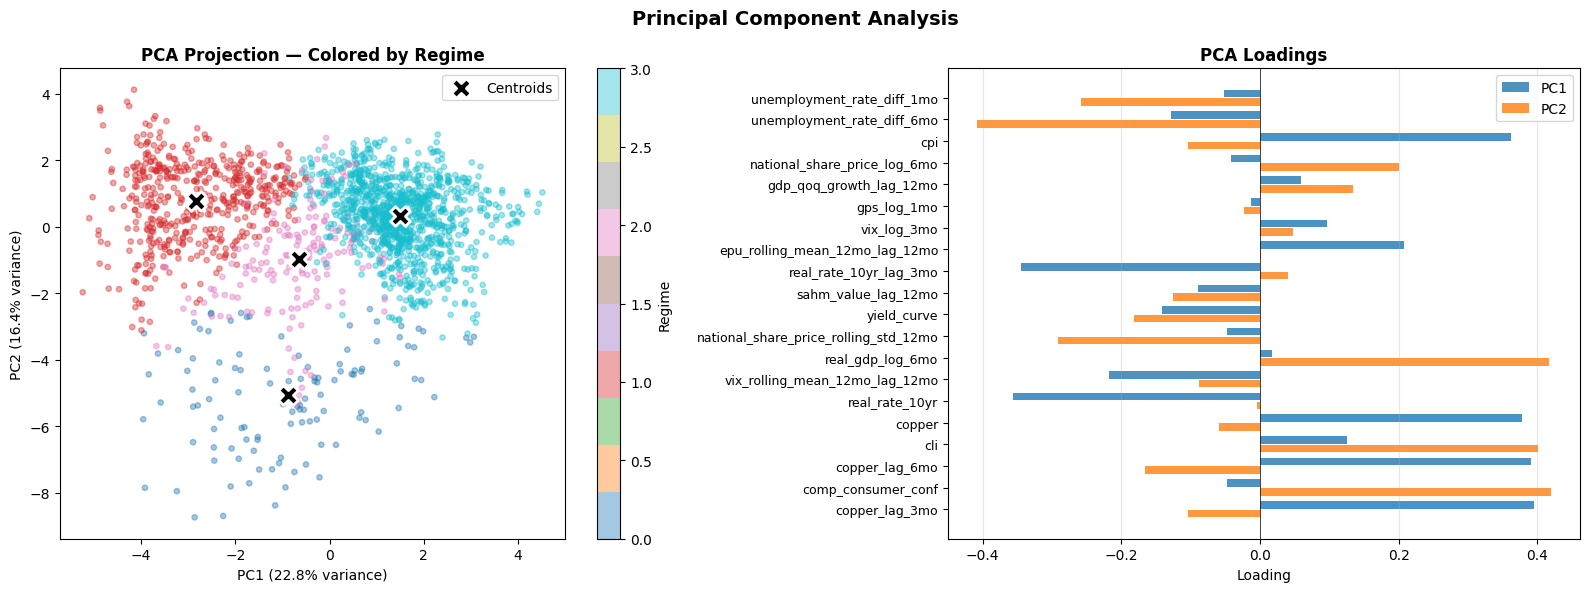

Explained variance: PC1=22.8%, PC2=16.4%, Total=39.2%


In [9]:
X_pca, pca, centers_pca = plot_pca_analysis(
    X_scaled, df_cluster['regime'].values, CLUSTER_FEATURES, OPTIMAL_K,
    centers_scaled=kmeans.cluster_centers_,
)

### PCA Interpretation

**PCA projection** captures 39.2% of total variance in 2 components:

- **PC1** (22.8%) primarily loads on **copper prices** and **CPI** (positive direction) versus **real interest rates** (negative direction), capturing the commodity/inflation vs. real-rate axis.
- **PC2** (16.4%) loads on **stock market volatility**, **unemployment changes**, and **VIX** (positive direction) versus **copper lags** and **GDP growth** (negative direction), capturing the stability-vs-stress axis.

In the scatter plot:
- **Regime 1** (low-commodity era) is clearly separated along PC1 due to its distinctively low copper prices.
- **Regime 0** (crisis) is partially separated along PC2 due to high volatility and unemployment surges.
- Substantial overlap between **Regimes 2 and 3** in PCA space indicates their differences lie in dimensions beyond PC1–PC2 (the remaining 60.8% of variance).

The black X markers show the cluster centroids, which are well-spaced in PCA space despite the overlap in individual observations — a hallmark of soft cluster boundaries in high-dimensional data.

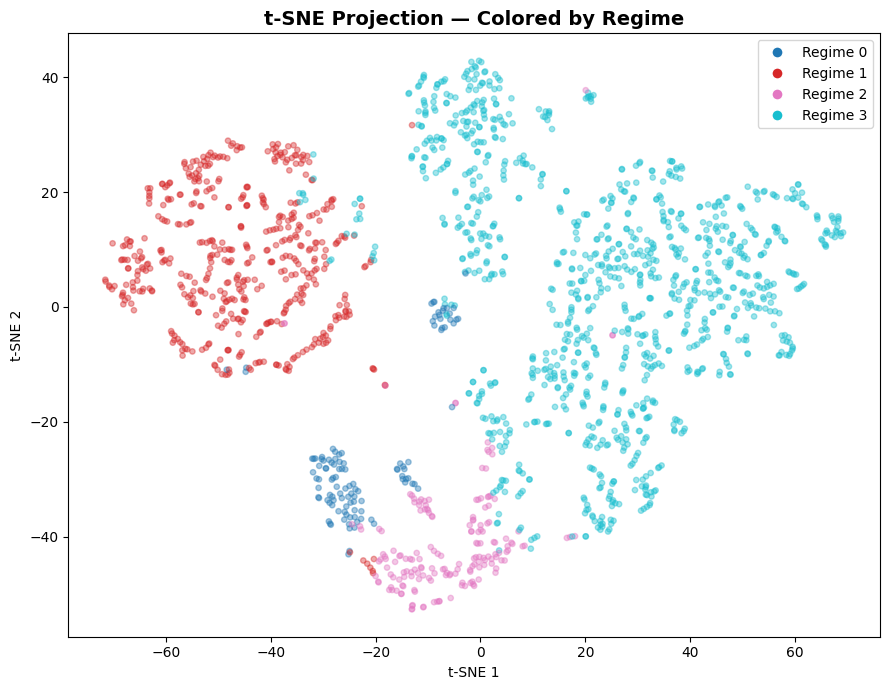

In [10]:
X_tsne = plot_tsne(X_scaled, df_cluster['regime'].values, OPTIMAL_K)

### t-SNE Interpretation

The t-SNE projection (shown at perplexity = 30) highlights non-linear neighborhood structure. In our perplexity sweep (15, 30, 50), the broad geometry is largely consistent:

- **Regime 1** repeatedly appears as a clearly separated region, consistent with its distinctive low-commodity-price profile.
- **Regime 3** occupies the largest diffuse region, indicating a broad low-volatility/low-rate state with substantial internal heterogeneity.
- **Regime 2** is typically more compact than Regime 3, consistent with a narrower recovery-like profile.
- **Regime 0** often appears fragmented into multiple nearby pockets, suggesting crisis observations may include multiple variants rather than a single tight cluster.

Because t-SNE is parameter-sensitive and non-metric, these patterns are best treated as **supporting visualization evidence** rather than definitive proof of manifold topology. Combined with PCA, they still support meaningful but soft regime boundaries.

## Post-hoc Recession Overlay

As a purely **interpretive** step (not an evaluation metric), we compare the discovered regimes to known OECD recession periods. This examines whether the unsupervised clustering naturally separates recessionary from non-recessionary conditions, without having used recession labels during clustering.

Post-hoc Recession Overlap Analysis
(Fraction of each regime's observations that fall during known OECD recessions)

  Regime 0:   89/112 during recession (79.5%)
  Regime 1:  170/491 during recession (34.6%)
  Regime 2:   26/175 during recession (14.9%)
  Regime 3:  407/1076 during recession (37.8%)

  Overall recession rate in dataset: 37.3%


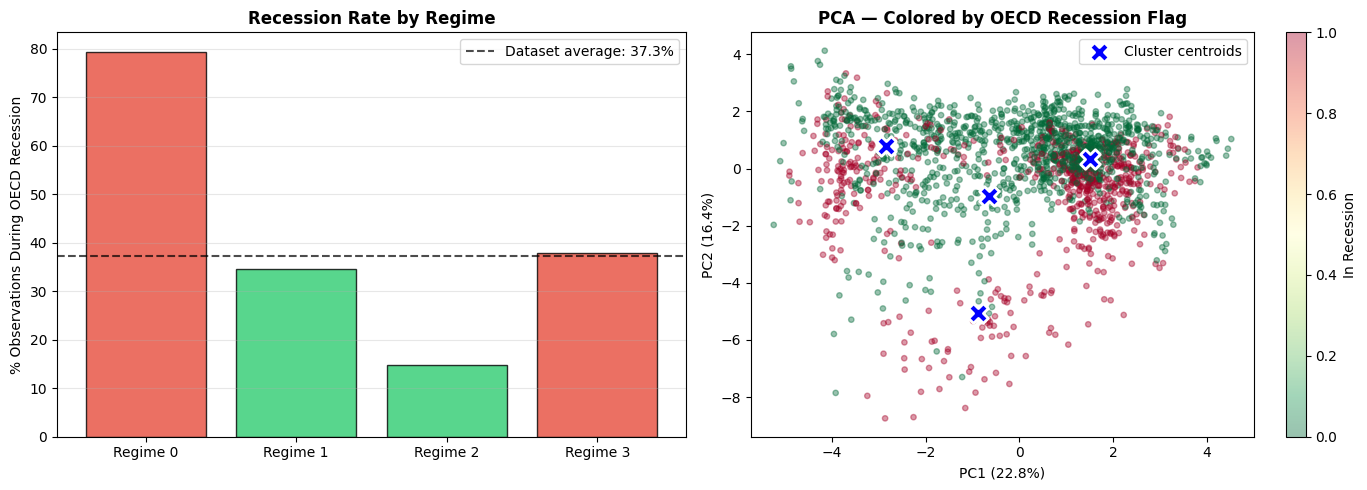

In [11]:
plot_recession_overlay(df_cluster, df_cluster['regime'].values, OPTIMAL_K,
                       X_pca, pca, centers_pca=centers_pca)

### Interpretation

The post-hoc recession comparison (not used during clustering) reveals a strong but imperfect correspondence:

| Regime | Recession Rate | vs. Baseline (37.3%) | Interpretation |
|--------|---------------|---------------------|----------------|
| Regime 0 | **79.5%** | +42.2 pp | Strongly recessionary — 4 out of 5 observations fall during OECD recessions |
| Regime 1 | 34.6% | −2.7 pp | Near baseline — mixes recession and non-recession periods |
| Regime 2 | **14.9%** | −22.4 pp | Strongly non-recessionary — captures expansion/recovery periods |
| Regime 3 | 37.8% | +0.5 pp | Near baseline — the dominant "normal" regime spans both states |

Key insights:
- **Regime 0 strongly captures recession periods** without being trained on recession labels, validating that the clustering discovers economically meaningful states.
- **Regime 2's low recession rate** (14.9%) despite high lagged stress indicators confirms its post-crisis recovery interpretation — the economy has exited recession but still carries its memory.
- **Regimes 1 and 3 near the baseline** indicates these regimes are defined by structural features (commodity prices, rate environment) rather than the business cycle.
- The PCA scatter colored by recession flag shows that recessions are partially but not fully separable in the first two principal components, explaining why the clustering captures recession signal through higher-dimensional feature combinations.

This asymmetry — one regime strongly recession-associated, one strongly non-recessionary, and two near-baseline — demonstrates that K-Means discovers a richer taxonomy than a binary recession/expansion classification.

## Cluster Stability Analysis

Robust clusters should produce consistent assignments regardless of random initialization. We run K-Means 50 times with different random seeds and measure agreement with the reference solution using the Adjusted Rand Index (ARI). ARI = 1 indicates identical assignments; ARI near 0 indicates random-level agreement.

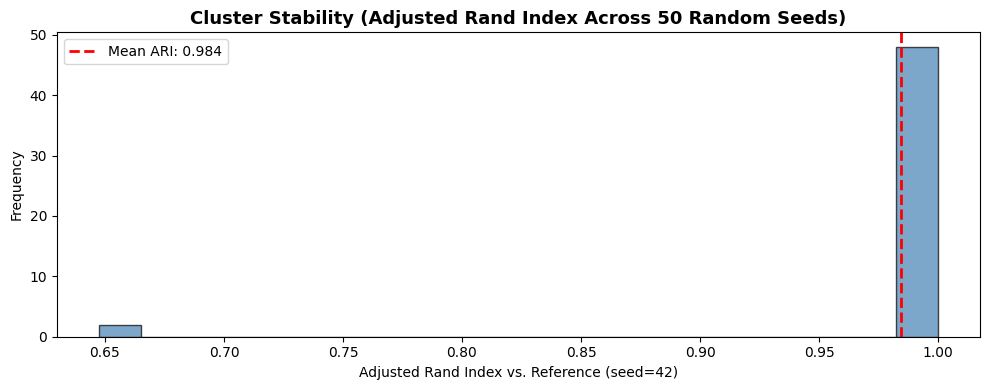

Stability Summary:
  Mean ARI: 0.9843
  Std ARI:  0.0688
  Min ARI:  0.6474
  Max ARI:  1.0000
  Clusters are highly stable across initializations.


In [12]:
N_SEEDS = 50
reference_labels = df_cluster['regime'].values
ari_scores = []

for seed in range(N_SEEDS):
    km_temp = KMeans(n_clusters=OPTIMAL_K, random_state=seed, n_init=10)
    temp_labels = km_temp.fit_predict(X_scaled)
    ari_scores.append(adjusted_rand_score(reference_labels, temp_labels))

plot_stability_ari(ari_scores, 'K-Means', N_SEEDS)

### Interpretation

The stability analysis shows that the discovered regimes are highly robust:

- **Mean ARI = 0.984** across 50 random initializations, meaning nearly identical cluster assignments regardless of starting conditions.
- **48 of 50 runs** produced ARI ≥ 0.95 (near-perfect agreement with the reference solution), indicating the algorithm consistently converges to the same global structure.
- **Minimum ARI = 0.647** from two outlier runs where the algorithm found a local minimum — minor occurrences that do not materially affect the overall stability.

This high stability confirms that the four-regime solution reflects genuine structure in the data rather than an artifact of a particular random seed. The K-Means objective landscape for this data has a dominant basin of attraction that nearly all initializations find.

## Summary

This analysis identified **four distinct economic regimes** across 9 countries and 17 years of monthly data using K-Means clustering on 20 multi-domain indicators. Clustering itself is unsupervised, but feature selection upstream was recession-target-informed, so conclusions should be interpreted as **target-informed regime discovery**.

### Discovered Regimes

| Regime | Share | Characterization | Recession Rate |
|--------|-------|-------------------|---------------|
| **Regime 0** | 6.0% | Acute crisis — falling GDP, surging unemployment, extreme stock volatility | 79.5% |
| **Regime 1** | 26.5% | Low-commodity era — early 2000s environment with low copper/CPI, moderate rates | 34.6% |
| **Regime 2** | 9.4% | Post-crisis recovery — high lagged stress, steep yield curve, improving current conditions | 14.9% |
| **Regime 3** | 58.0% | Broad low-volatility/low-rate state with mixed cycle phases | 37.8% |

### Key Findings

1. **k = 4** is selected as a practical operating point: silhouette score peaks at 0.240 and Davies-Bouldin reaches its minimum at 1.528, with an elbow around 4–5. (Calinski-Harabasz prefers fewer clusters, peaking at k = 2.)

2. **Regimes capture more than a binary cycle label.** The four clusters represent a richer taxonomy: acute crisis, a commodity-price era, post-crisis recovery, and a broad low-volatility/low-rate state.

3. **Temporal coherence**: Regime transitions align with known economic events (2008 GFC, European debt crisis, post-crisis expansion) and show both global synchronization (crisis entry) and country-specific divergence (recovery timing).

4. **Post-hoc recession alignment is asymmetric**: Regime 0 is strongly recession-associated (79.5%), Regime 2 is strongly non-recessionary (14.9%), while Regimes 1 and 3 are near baseline.

5. **High stability**: Mean ARI of 0.984 across 50 random seeds indicates assignments are robust to initialization.

### Limitations

- The **silhouette score of 0.24** indicates soft cluster boundaries — economic regimes blend into one another rather than forming discrete, well-separated groups.
- **PCA captures only 39.2%** of variance in 2 components, so 2D visualizations substantially compress the actual cluster structure.
- **Regime 1 is partially period-specific** (early 2000s low-commodity era), which may limit generalizability to future data with different commodity price levels.
- Two of four regimes (0 and 2) have **elevated misassignment rates** (15–20% negative silhouette values), indicating some boundary observations are ambiguously classified.
- Since upstream feature selection used recession-target information, this is not a fully target-agnostic latent-state pipeline.